In [1]:
import os
import sys
from sys import path
sys.path.append(os.path.expanduser('~/albatros_analysis'))
import numpy as np 
import numba as nb
import time
from scipy import linalg
from scipy import stats
from matplotlib import pyplot as plt
from datetime import datetime as dt
from src.correlations import baseband_data_classes as bdc
from src.utils import baseband_utils as butils
from src.utils import orbcomm_utils as outils
from scipy.optimize import least_squares, minimize_scalar
import json
import random
from datetime import datetime, timezone
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from skyfield.api import load, EarthSatellite, Topos, wgs84
import skyfield.api as sf
from scipy.linalg import block_diag
import math
from scipy.linalg import cho_factor, cho_solve, inv
from scipy.interpolate import interp1d
from src.utils import orbcomm_utils as outils
from scripts.xcorr import helper as hxc

BDC is using numpy
BDC is using numpy


In [2]:
# VISIBILITY FUNCTIONS

@nb.njit(parallel=True)
def apply_delay(arr, out, delay, freqs):
    # apply delay to an array of complex electric field or their correlation
    # does exp( j 2 pi nu tau) sign of tau is user dependent
    # freqs should correspond to the columns of the nspec x nchan array
    nspec = arr.shape[0]
    nchan = arr.shape[1]
    for i in nb.prange(nspec):
        for j in range(nchan):
            out[i, j] = arr[i, j] * np.exp(2j * np.pi * freqs[j] * delay[i])
    return out

@nb.njit(parallel=True)
def xcorr_avg(arr1,arr2,acclen):
    #helper function
    nblocks = arr1.shape[0]//acclen
    nchan = arr1.shape[1]
    out = np.zeros((nblocks,nchan),dtype=arr1.dtype)
    for i in nb.prange(nblocks):
        for j in range(acclen):
            for k in range(nchan):
                out[i,k] += arr1[i*acclen + j,k]*np.conj(arr2[i*acclen + j,k])
        out[i,:]/=acclen
    return out

In [3]:
T_SPECTRA = 4096/250e6
nspectra = int(5e6)

t_start = 1753215950
#t_end = 1753205056
t_end = t_start + nspectra*T_SPECTRA
t_pulse = t_end - t_start
t_pulse_rounded = int(t_pulse)+1
satID = 59051

specnum_offsets = [0, -1884333]
paths = np.array(["/scratch/mohanagr/summer_2025/baseband/mars1", "/scratch/mohanagr/summer_2025/baseband/mars2"])
coords = np.array([[79.41716147, -90.76723869, 187.9577], [79.41719805, -90.75873919, 183.0684]])

tle_path = outils.get_tle_file(t_start, "/project/rrg-sievers/mohanagr/OCOMM_TLES")

print('t start', t_start)
print('t end', t_end)
print('pulse time', t_pulse_rounded)

t start 1753215950
t end 1753216031.92
pulse time 82


In [4]:
idxs, files = hxc.get_init_info_all_ant(t_start, t_end, specnum_offsets, paths)

1753215939 1753215994
Using delta of 65.0 seconds to check for gaps between files
took 0.066 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars1/17532/1753215939.raw
1753215908 1753216016
Using delta of 64.0 seconds to check for gaps between files
took 0.065 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars2/17532/1753215908.raw
specnums [np.int64(965696155), np.int64(967555069)]
spec offsets [       0 -1884333]

PROCESSING ANTENNA 0
initial offset wrt ref ant 0
idxs before correction 671387 671387
spec offset 0 init offset 0
correction 0
after correction 671387 671387

PROCESSING ANTENNA 1
initial offset wrt ref ant -1858914
idxs before correction 671387 2563477
spec offset -1884333 init offset -1858914
correction -25419
after correction 671387 2588896


In [5]:
channel_start, channel_end = 1836, 1838
freqs = 250e6 * (1 - np.arange(channel_start, channel_end) / 4096)

channels = np.asarray(bdc.get_header(files[0][0])["channels"],dtype='int64')
chanstart = np.where(channels == channel_start)[0][0]
chanend = np.where(channels == channel_end)[0][0]

nchans = chanend - chanstart
print(chanstart, chanend)
print(freqs)

Not reading any data
286 288
[1.37939453e+08 1.37878418e+08]


catalog #59051 epoch 2025-07-22 20:03:55 UTC
one delay prediction: 0.02330756187438965
(5000000,)
(2500000,)


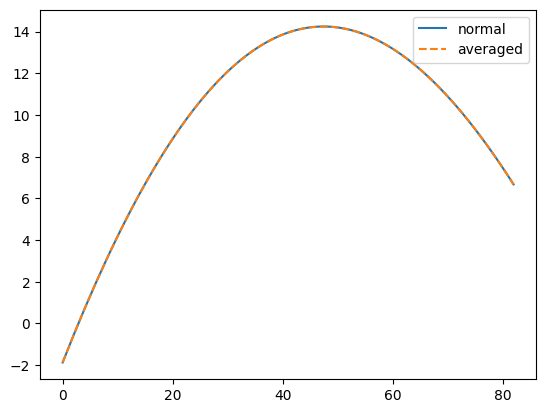

In [6]:
d = outils.get_sat_delay(coords[0], coords[1], tle_path, t_start, t_pulse_rounded+1, satID, altaz=False)

times = np.arange(0, nspectra) * T_SPECTRA
delays = np.interp(times, np.arange(0, t_pulse_rounded+1), d)
times_av = (np.arange(0, nspectra/2) + 0.5)* 2 * T_SPECTRA
delays_av = np.interp(times_av, np.arange(0, t_pulse_rounded+1), d)
print(delays.shape)
print(delays_av.shape)

plt.plot(times, np.unwrap(np.angle(np.exp(2j*np.pi*delays*freqs[0]))), label='normal')
plt.plot(times_av, np.unwrap(np.angle(np.exp(2j*np.pi*delays_av*freqs[0]))), label = 'averaged', linestyle='--')
plt.legend()

In [7]:
ant1 = bdc.BasebandFileIterator(
                files[0],
                0,
                idxs[0],
                nspectra,
                2,
                chanstart=chanstart ,
                chanend=chanend,
                type="float",
            )

ant2 = bdc.BasebandFileIterator(
                files[1],
                0,
                idxs[1],
                nspectra,
                2,
                chanstart=chanstart,
                chanend=chanend,
                type="float",
            )

for idx, (a1, a2) in enumerate(zip(ant1, ant2)):
    data1 = a1['pol0']
    data2 = a2['pol0']
    break

ACCLEN RECEIVED IS 5000000
took 0.065 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars1/17532/1753215939.raw
START SPECNUM IS 965696155 obj start at 965024768
ACCLEN RECEIVED IS 5000000
took 0.063 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars2/17532/1753215908.raw
START SPECNUM IS 967580488 obj start at 964991592
print shape of my pols 2607301 2
took 0.086 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars1/17532/1753215994.raw
print shape of my pols 2392699 2
print shape of my pols 689792 2
took 0.081 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars2/17532/1753215963.raw
print shape of my pols 3278688 2
took 0.062 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars2/17532/1753216016.raw
print shape of my pols 1031520 2


In [8]:
data1_av = data1.reshape(-1, 2, 2).mean(axis=1)
data2_av = data2.reshape(-1, 2, 2).mean(axis=1)

print(data1.shape)
print(data1_av.shape)

(5000000, 2)
(2500000, 2)


Text(0.5, 0.98, 'Unphased, Unaveraged')

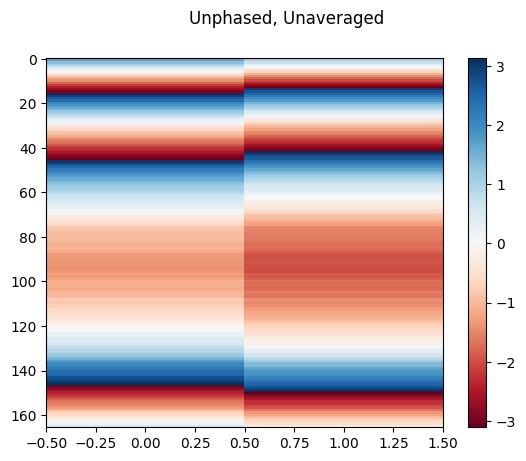

In [9]:
vis = xcorr_avg(data1, data2, 30000)
im = plt.imshow(np.angle(vis), cmap='RdBu', aspect='auto', interpolation='none')
cbar=plt.colorbar(im)
plt.suptitle('Unphased, Unaveraged')


Text(0.5, 0.98, 'Unphased, Averaged')

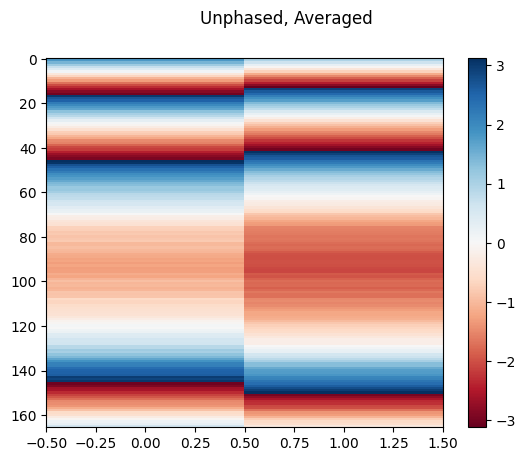

In [10]:
vis = xcorr_avg(data1_av, data2_av, 15000)
im = plt.imshow(np.angle(vis), cmap='RdBu', aspect='auto', interpolation='none')
cbar=plt.colorbar(im)
plt.suptitle('Unphased, Averaged')

In [11]:
data2_delayed = np.zeros_like(data2)
data2_delayed = apply_delay(data2, data2_delayed, -delays, freqs)

data2_av_delayed = np.zeros_like(data2_av)
data2_av_delayed = apply_delay(data2_av, data2_av_delayed, -delays_av, freqs)

Text(0.5, 0.98, 'Delayed, Unaveraged')

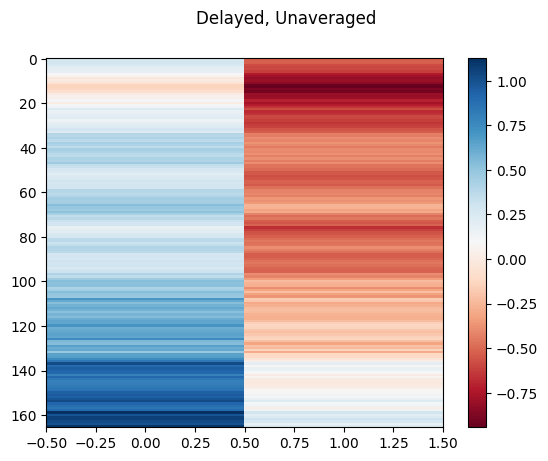

In [12]:
vis = xcorr_avg(data1, data2_delayed, 30000)
im = plt.imshow(np.angle(vis)[:,:], cmap='RdBu', aspect='auto', interpolation='none')
cbar=plt.colorbar(im)
plt.suptitle('Delayed, Unaveraged')

Text(0.5, 0.98, 'Delayed, Averaged')

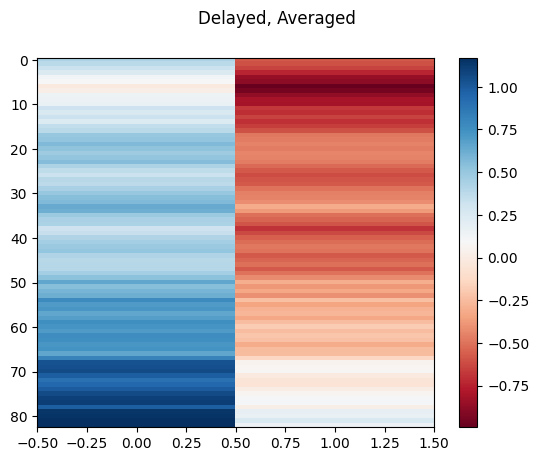

In [13]:
vis = xcorr_avg(data1_av, data2_av_delayed, 30000)
im = plt.imshow(np.angle(vis), cmap='RdBu', aspect='auto', interpolation='none')
cbar=plt.colorbar(im)
plt.suptitle('Delayed, Averaged')

In [17]:
print('data shape', data1_av.shape)
print('both size in MB', 2*int(data1_av.nbytes/1024**2))
print('\ndelays shape', delays_av.shape)
print('delays in MB', int(delays_av.nbytes/1024**2))
print('\nfreqs shape', freqs.shape)
print('freqs in bytes', freqs.nbytes)

data shape (2500000, 2)
both size in MB 76

delays shape (2500000,)
delays in MB 19

freqs shape (2,)
freqs in bytes 16


In [16]:
np.savez("/scratch/thomasb/summer_school.npz", MARS1=data1_av, MARS2=data2_av, freqs = freqs, delays=delays_av)

In [47]:
disk = np.load("/scratch/thomasb/summer_school.npz")
print(disk)

NpzFile '/scratch/thomasb/summer_school.npz' with keys: baseband_data, delays, frequencies
